
## Notebook 2: Representación vectorial del texto

**Autor:** Ana Gabriela García Rivas

**Fecha:** Junio 2026

**Dataset:** WELFake —  Artículos de noticias (reales y falsas)

---
## 1. Carga de datos 

In [1]:
!pip install -q gensim transformers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import time
import os
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

import scipy.sparse as sp

#Gensim para Word2Vec
from gensim.models import Word2Vec

#HuggingFace Transformers para BERT
from transformers import AutoTokenizer, AutoModel
import torch

print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No hay GPU activa')

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

#GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo para BERT: {DEVICE}')
print('Librerías cargadas correctamente.')


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


CUDA disponible: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo para BERT: cuda
Librerías cargadas correctamente.


In [2]:
import os
print('Directorio actual:', os.getcwd())

ruta = os.getcwd()

train_path = os.path.join(ruta, 'welfake_train.csv')
val_path   = os.path.join(ruta, 'welfake_val.csv')
test_path  = os.path.join(ruta, 'welfake_test.csv')

for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Datos no encontrados: {path}\n'
        )

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path) 

#Se revisa que no haya valores nulos en 'text_full' y que 'label' sea de tipo entero
for d in [train_df, val_df, test_df]:
    d['text_full'] = d['text_full'].fillna('').astype(str)
    d['label']     = d['label'].astype(int)

print(f'Train : {len(train_df):,} filas')
print(f'Val   : {len(val_df):,} filas')
print(f'Test  : {len(test_df):,} filas')

X_train_raw = train_df['text_full'].tolist()
X_val_raw   = val_df['text_full'].tolist()
X_test_raw  = test_df['text_full'].tolist()

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

Directorio actual: c:\Users\anaes\OneDrive\Escritorio\MASTER TELECO\2do CUATRI\trabajos de datos\note2
Train : 50,909 filas
Val   : 6,364 filas
Test  : 6,364 filas


---
## 2. Preprocesamiento 

Se preparan dos versiones del texto: una versión normalizada para TF-IDF y Word2Vec, y una versión con limpieza mínima para BERT. 

In [3]:
#Stopwords base + términos de alto riesgo de leakage
BASE_STOP_WORDS = set(stopwords.words('english'))

LEAKAGE_STOPWORDS = [
    #Posibles fuentes asociadas a una clase
    'reuters', 'associated', 'press', 'ap',
    'infowars', 'natural', 'news',
    'politifact', 'snopes',
    'yournewswire', 'activistpost', 'beforeitsnews',
    'worldnewsdailyreport',

    #Palabras que pueden actuar como etiqueta directa
    'fake', 'false', 'true', 'real',
    'partially', 'partial',
    'label', 'category'
]


STOP_WORDS = BASE_STOP_WORDS.union(LEAKAGE_STOPWORDS)

def limpiar_texto(texto, tokenizar=False):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)   #URLs
    texto = re.sub(r'@\w+', '', texto)              #menciones
    texto = re.sub(r'[^a-z\s]', ' ', texto)         #letras
    texto = re.sub(r'\s+', ' ', texto).strip()       #espacios 

    if tokenizar:
        tokens = [t for t in texto.split() if t not in STOP_WORDS and len(t) > 2]
        return tokens
    else:
        #Para TF-IDF no quitamos stopwords
        return texto


print('Preprocesando textos para string limpio (TF-IDF)')
t0 = time.time()
X_train_clean = [limpiar_texto(t) for t in X_train_raw]
X_val_clean   = [limpiar_texto(t) for t in X_val_raw]
X_test_clean  = [limpiar_texto(t) for t in X_test_raw]


print('Tokenizando para Word2Vec')
t0 = time.time()
X_train_tok = [limpiar_texto(t, tokenizar=True) for t in X_train_raw]
X_val_tok   = [limpiar_texto(t, tokenizar=True) for t in X_val_raw]
X_test_tok  = [limpiar_texto(t, tokenizar=True) for t in X_test_raw]


#Ejemplos
print(f'\nEjemplo texto limpio (120 caracteres):')
print(X_train_clean[0][:120])
print(f'Ejemplo tokenizado (primeros 15 tokens):')
print(X_train_tok[0][:15])

Preprocesando textos para string limpio (TF-IDF)
Tokenizando para Word2Vec

Ejemplo texto limpio (120 caracteres):
judge who could replace scalia has no track record on social issues except this big ruling judge sri srinivasan is a pos
Ejemplo tokenizado (primeros 15 tokens):
['judge', 'could', 'replace', 'scalia', 'track', 'record', 'social', 'issues', 'except', 'big', 'ruling', 'judge', 'sri', 'srinivasan', 'possible']


In [4]:
#Tamaño de vocabulario TF-IDF 

#Vocabulario total 
from sklearn.feature_extraction.text import CountVectorizer

cv_diagnostico = CountVectorizer(min_df=1)
cv_diagnostico.fit(X_train_clean)
vocab_total = len(cv_diagnostico.vocabulary_)
print(f'Vocabulario total (sin filtros)       : {vocab_total:,} terminos')

cv_min3 = CountVectorizer(min_df=3)
cv_min3.fit(X_train_clean)
vocab_min3 = len(cv_min3.vocabulary_)
print(f'Vocabulario con min_df=3              : {vocab_min3:,} terminos')

cv_min3_max90 = CountVectorizer(min_df=3, max_df=0.90)
cv_min3_max90.fit(X_train_clean)
vocab_filtrado = len(cv_min3_max90.vocabulary_)
print(f'Vocabulario con min_df=3, max_df=0.90 : {vocab_filtrado:,} terminos')


Vocabulario total (sin filtros)       : 173,148 terminos
Vocabulario con min_df=3              : 68,665 terminos
Vocabulario con min_df=3, max_df=0.90 : 68,659 terminos


In [5]:
#Stopwords adicional para el vectorizador TF-IDF
EXTRA_STOPWORDS = list(LEAKAGE_STOPWORDS)

print(f'Stopwords adicionales por posible leakage de fuente/etiqueta: {EXTRA_STOPWORDS}')

Stopwords adicionales por posible leakage de fuente/etiqueta: ['reuters', 'associated', 'press', 'ap', 'infowars', 'natural', 'news', 'politifact', 'snopes', 'yournewswire', 'activistpost', 'beforeitsnews', 'worldnewsdailyreport', 'fake', 'false', 'true', 'real', 'partially', 'partial', 'label', 'category']


Estas stopwords adicionales se incorporan como medida de control frente a posibles atajos léxicos. Incluyen términos de fuente detectados en el Notebook 1 (`reuters`, `infowars`, etc.) y palabras que podrían coincidir con las etiquetas (`fake`, `false`, `true`, `real`, etc.).

La lista se aplica a TF-IDF y Word2Vec. En el caso de BERT, se aplica una limpieza mínima específica más adelante para eliminar estos términos sin destruir la estructura general del texto.

---
## 3. Representación 1: TF-IDF

Asigna a cada palabra un peso que combina:
- **TF (Term Frequency):** cuántas veces aparece la palabra en ese documento
- **IDF (Inverse Document Frequency):** penaliza las palabras que aparecen en muchos documentos (son poco informativas)


In [6]:
print('Entrenando TF-IDF')
t0 = time.time()

tfidf = TfidfVectorizer(
    max_features=50_000,     #vocabulario máximo
    min_df=3,                #ignorar términos
    max_df=0.90,             #ignorar términos muy comunes
    ngram_range=(1, 2),      #unigramas y bigramas
    sublinear_tf=True,       
    stop_words=list(STOP_WORDS),
    strip_accents='unicode'
)

#Se ajusta el vectorizador solo en entrenamiento para evitar leakage.
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print(f'Listo en {time.time()-t0:.1f}s')
print(f'\nForma de la matriz TF-IDF:')
print(f'  Train : {X_train_tfidf.shape}  ({X_train_tfidf.nnz:,} elementos no-cero)')
print(f'  Val   : {X_val_tfidf.shape}')
print(f'  Test  : {X_test_tfidf.shape}')
print(f'\nTamaño vocabulario: {len(tfidf.vocabulary_):,} términos')

#Terminos con mayor peso IDF (los más informativos)
idf_scores = tfidf.idf_
vocab = tfidf.get_feature_names_out()
top_idf_idx = np.argsort(idf_scores)[-15:][::-1]
print(f'\nTérminos más informativos (IDF más alto):')
for i in top_idf_idx:
    print(f'  {vocab[i]:<30} IDF={idf_scores[i]:.3f}')

Entrenando TF-IDF
Listo en 60.2s

Forma de la matriz TF-IDF:
  Train : (50909, 50000)  (12,547,675 elementos no-cero)
  Val   : (6364, 50000)
  Test  : (6364, 50000)

Tamaño vocabulario: 50,000 términos

Términos más informativos (IDF más alto):
  haganah                        IDF=10.452
  klinsmann                      IDF=10.452
  keurig                         IDF=10.452
  distribute cocaine             IDF=10.452
  mr perdue                      IDF=10.452
  mr santiago                    IDF=10.452
  mr keillor                     IDF=10.452
  ms ferrante                    IDF=10.452
  een                            IDF=10.452
  ms graswald                    IDF=10.452
  mr guo                         IDF=10.452
  mr breslin                     IDF=10.452
  lida                           IDF=10.452
  mr doig                        IDF=10.452
  nuclear primacy                IDF=10.452


In [7]:
#Guardar matrices TF-IDF
sp.save_npz('tfidf_train.npz', X_train_tfidf)
sp.save_npz('tfidf_val.npz',   X_val_tfidf)
sp.save_npz('tfidf_test.npz',  X_test_tfidf)

import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print('Guardado: tfidf_train.npz, tfidf_val.npz, tfidf_test.npz')
print('Guardado: tfidf_vectorizer.pkl')

Guardado: tfidf_train.npz, tfidf_val.npz, tfidf_test.npz
Guardado: tfidf_vectorizer.pkl


---
## 4. Representación 2: Word2Vec


Aprende embeddings de palabras de forma que palabras con contextos similares queden cerca en el espacio vectorial.  
Para representar un **documento** se calcula **promedio** de los embeddings de todas sus palabras.


In [8]:
print('Entrenando Word2Vec sobre el corpus de train...')
t0 = time.time()

w2v_model = Word2Vec(
    sentences=X_train_tok,    #lista de listas de tokens
    vector_size=300,          #dimensión de los embeddings
    window=5,                 #palabras por lado
    min_count=3,              #ignorar palabras con menos de 3 ocurrencias
    workers=4,               
    epochs=5,                 #épocas de entrenamiento
    sg=1,                     
    seed=SEED
)

print(f'Entrenado en {time.time()-t0:.1f}s')
print(f'Vocabulario Word2Vec: {len(w2v_model.wv):,} palabras')
print(f'Dimensión de cada embedding: {w2v_model.vector_size}')

def mostrar_similares(modelo, palabra, topn=5):
    if palabra in modelo.wv:
        print(f'\nPalabras más similares a "{palabra}":')
        for word, score in modelo.wv.most_similar(palabra, topn=topn):
            print(f'  {word:<20} {score:.4f}')
    else:
        print(f'\nLa palabra "{palabra}" no está en el vocabulario Word2Vec.')

mostrar_similares(w2v_model, 'election', topn=5)
mostrar_similares(w2v_model, 'government', topn=5)

Entrenando Word2Vec sobre el corpus de train...
Entrenado en 226.6s
Vocabulario Word2Vec: 80,659 palabras
Dimensión de cada embedding: 300

Palabras más similares a "election":
  elections            0.7429
  downballot           0.5832
  electoral            0.5817
  getters              0.5685
  determinative        0.5664

Palabras más similares a "government":
  goverment            0.5781
  mujahadin            0.5607
  reestablish          0.5604
  governments          0.5577
  moallem              0.5562


In [9]:
def doc_vec(tokens, model, vector_size=300):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)


print('Representaciones Word2Vec para train/val/test')
t0 = time.time()

X_train_w2v = np.array([doc_vec(tok, w2v_model) for tok in X_train_tok])
X_val_w2v   = np.array([doc_vec(tok, w2v_model) for tok in X_val_tok])
X_test_w2v  = np.array([doc_vec(tok, w2v_model) for tok in X_test_tok])

print(f'Listo en {time.time()-t0:.1f}s')
print(f'Forma matrices Word2Vec:')
print(f'  Train : {X_train_w2v.shape}')
print(f'  Val   : {X_val_w2v.shape}')
print(f'  Test  : {X_test_w2v.shape}')

#Cuántos documentos tienen al menos una palabra en el vocabulario
cobertura = np.sum(X_train_w2v.sum(axis=1) != 0) / len(X_train_w2v) * 100
print(f'\nCobertura (documentos con al menos 1 token conocido): {cobertura:.1f}%')

Representaciones Word2Vec para train/val/test
Listo en 25.8s
Forma matrices Word2Vec:
  Train : (50909, 300)
  Val   : (6364, 300)
  Test  : (6364, 300)

Cobertura (documentos con al menos 1 token conocido): 99.9%


In [10]:
#Guardar embeddings Word2Vec
np.save('w2v_train.npy', X_train_w2v)
np.save('w2v_val.npy',   X_val_w2v)
np.save('w2v_test.npy',  X_test_w2v)
w2v_model.save('word2vec_model.bin')
print('Guardado: w2v_train.npy, w2v_val.npy, w2v_test.npy')
print('Guardado: word2vec_model.bin')

Guardado: w2v_train.npy, w2v_val.npy, w2v_test.npy
Guardado: word2vec_model.bin


In [11]:
import torch
print(torch.cuda.is_available())

True


In [12]:
def cobertura_word2vec(textos_tokenizados, modelo):
    total_tokens = 0
    tokens_cubiertos = 0

    for tokens in textos_tokenizados:
        total_tokens += len(tokens)
        tokens_cubiertos += sum(1 for token in tokens if token in modelo.wv)

    cobertura = tokens_cubiertos / total_tokens * 100 if total_tokens > 0 else 0
    return total_tokens, tokens_cubiertos, cobertura

total_train, cub_train, cov_train = cobertura_word2vec(X_train_tok, w2v_model)
total_val, cub_val, cov_val = cobertura_word2vec(X_val_tok, w2v_model)
total_test, cub_test, cov_test = cobertura_word2vec(X_test_tok, w2v_model)

print(f'Cobertura Word2Vec train: {cov_train:.2f}% ({cub_train:,}/{total_train:,})')
print(f'Cobertura Word2Vec val  : {cov_val:.2f}% ({cub_val:,}/{total_val:,})')
print(f'Cobertura Word2Vec test : {cov_test:.2f}% ({cub_test:,}/{total_test:,})')

Cobertura Word2Vec train: 99.27% (15,411,999/15,525,249)
Cobertura Word2Vec val  : 98.80% (1,921,639/1,944,913)
Cobertura Word2Vec test : 98.77% (1,907,041/1,930,836)


La cobertura de Word2Vec permite comprobar si el vocabulario aprendido en train representa adecuadamente los textos de validation y test. Una cobertura alta indica que el modelo podrá construir embeddings documentales para la mayoría de tokens relevantes. Si la cobertura fuese baja, Word2Vec perdería información en documentos con muchas palabras fuera de vocabulario.

## Control de data leakage en la vectorización

Para evitar data leakage, todos los objetos que aprenden información del corpus se ajustan solo con el conjunto de entrenamiento. En concreto:

- `TfidfVectorizer` se entrena con `X_train_clean` mediante `fit_transform`.
- Validation y test se transforman después con `transform`, sin recalcular el vocabulario.
- Word2Vec se entrena únicamente con los textos tokenizados de train.


---
## 5. Representación 3: Embeddings BERT

Modelo Transformer bidireccional preentrenado en grandes corpus de texto. A diferencia de Word2Vec, los embeddings son **contextuales**: la misma palabra tiene representaciones distintas según su contexto en la frase.

In [13]:
#Parámetros BERT / DistilBERT
import os
import re
import time
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'distilbert-base-uncased'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MAX_LEN = 256
BATCH_SIZE = 16
N_SAMPLE = 3000
tokenizer_tmp = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Modelo: {MODEL_NAME}')
print(f'Dispositivo: {DEVICE}')
print(f'Max tokens: {MAX_LEN}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Muestra: {N_SAMPLE if N_SAMPLE else "dataset completo"}')

Modelo: distilbert-base-uncased
Dispositivo: cuda
Max tokens: 256
Batch size: 16
Muestra: 3000


In [14]:
#Truncamiento
def porcentaje_truncados(textos, tokenizer, max_len):
    longitudes = [
        len(tokenizer.encode(str(t), add_special_tokens=True, truncation=False))
        for t in textos
    ]
    longitudes = np.array(longitudes)
    pct_truncados = np.mean(longitudes > max_len) * 100
    return longitudes, pct_truncados

n_muestra_bert = min(2000, len(X_train_raw))
idx_muestra_bert = np.random.default_rng(SEED).choice(
    len(X_train_raw),
    size=n_muestra_bert,
    replace=False
)

muestra_bert_len = [X_train_raw[i] for i in idx_muestra_bert]

long_train_bert, pct_trunc_train = porcentaje_truncados(
    muestra_bert_len,
    tokenizer_tmp,
    MAX_LEN
)

print(f'Porcentaje estimado de textos truncados con MAX_LEN={MAX_LEN}: {pct_trunc_train:.2f}%')
print(f'Longitud media estimada en tokens BERT: {long_train_bert.mean():.1f}')
print(f'Percentil 75: {np.percentile(long_train_bert, 75):.0f}')
print(f'Percentil 90: {np.percentile(long_train_bert, 90):.0f}')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (863 > 512). Running this sequence through the model will result in indexing errors


Porcentaje estimado de textos truncados con MAX_LEN=256: 78.35%
Longitud media estimada en tokens BERT: 694.0
Percentil 75: 880
Percentil 90: 1401


In [15]:
print(f'Cargando tokenizador y modelo {MODEL_NAME}...')
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model     = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()              
bert_model.to(DEVICE)
print('Modelo cargado.')

#Ejemplo
ejemplo = X_train_raw[0][:200]
tokens_ej = tokenizer_bert(ejemplo, return_tensors='pt', truncation=True, max_length=MAX_LEN)
print(f'\nEjemplo de tokenización:')
print(f'  Texto original: "{ejemplo[:80]}..."')
print(f'  Número de tokens: {tokens_ej["input_ids"].shape[1]}')

Cargando tokenizador y modelo distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado.

Ejemplo de tokenización:
  Texto original: "JUDGE WHO COULD REPLACE SCALIA Has No Track Record On Social Issues EXCEPT This ..."
  Número de tokens: 45


In [16]:
def get_bert_embeddings(texts, tokenizer, model, max_len, batch_size, device):
   
    all_embeddings = []
    n_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():  #no calcular gradientes (solo inferencia)
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]

            #Tokenizar el batch
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors='pt'
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            #Forward pass
            outputs = model(**encoded)

            #Extraer embedding del [CLS] (primer token, índice 0)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

            #Progreso
            batch_num = i // batch_size + 1
            if batch_num % 10 == 0 or batch_num == n_batches:
                print(f'  Batch {batch_num}/{n_batches}', end='\r')

    return np.vstack(all_embeddings)

#Preparar textos para BERT y generar embeddings
#Terminos eliminados para evitar atajos
leak_term_bert = [
    #Fuentes
    'reuters', 'associated press',
    'infowars', 'natural news',
    'politifact', 'snopes',
    'yournewswire', 'activistpost',
    'beforeitsnews', 'worldnewsdailyreport',

    #Palabras/etiqueta
    'fake', 'false', 'partially false',
    'true', 'real',
    'label', 'category'
]

def limpiar_minimo(texto):
    texto = str(texto)
    texto = re.sub(r'http\S+|www\S+', '', texto)

    texto_lower = texto.lower()
    for term in leak_term_bert:
        patron = r'\b' + re.escape(term) + r'\b'
        texto_lower = re.sub(patron, ' ', texto_lower)

    texto_lower = re.sub(r'\s+', ' ', texto_lower).strip()
    return texto_lower

print('Preparando textos para BERT')
X_train_bert_raw = [limpiar_minimo(t) for t in X_train_raw]
X_val_bert_raw   = [limpiar_minimo(t) for t in X_val_raw]
X_test_bert_raw  = [limpiar_minimo(t) for t in X_test_raw]

print('Ejemplo texto para BERT (primeros 120 caracteres):')
print(X_train_bert_raw[0][:120])
print('(BERT conserva estructura general, pero se eliminan términos de fuente/etiqueta de alto riesgo)')

#Muestra para EDA
n_sample_real = min(N_SAMPLE, len(X_train_bert_raw))
idx_sample = np.random.default_rng(SEED).choice(
    len(X_train_bert_raw),
    size=n_sample_real,
    replace=False
)

X_bert_sample = [X_train_bert_raw[i] for i in idx_sample]
y_bert_sample = y_train[idx_sample]

print(f'\nGenerando embeddings BERT para muestra de {n_sample_real} documentos...')
t0 = time.time()

bert_embeddings_sample = get_bert_embeddings(
    X_bert_sample,
    tokenizer_bert,
    bert_model,
    MAX_LEN,
    BATCH_SIZE,
    DEVICE
)

print(f'\nListo en {time.time()-t0:.1f}s')

np.save('bert_sample.npy', bert_embeddings_sample)
np.save('bert_sample_y.npy', y_bert_sample)
print('Guardado: bert_sample.npy y bert_sample_y.npy')


if torch.cuda.is_available():
    print('Generando embeddings BERT — Train completo (limpieza minima, url y terminos fuentes/etiquetas)...')
    t0 = time.time()
    X_train_bert = get_bert_embeddings(
        X_train_bert_raw,
        tokenizer_bert,
        bert_model,
        MAX_LEN,
        BATCH_SIZE,
        DEVICE
    )
    print(f'\nTrain listo en {time.time()-t0:.1f}s — shape: {X_train_bert.shape}')

    print('Generando embeddings BERT — Val')
    X_val_bert = get_bert_embeddings(
        X_val_bert_raw,
        tokenizer_bert,
        bert_model,
        MAX_LEN,
        BATCH_SIZE,
        DEVICE
    )
    print(f'Val listo — shape: {X_val_bert.shape}')

    print('Generando embeddings BERT — Test')
    X_test_bert = get_bert_embeddings(
        X_test_bert_raw,
        tokenizer_bert,
        bert_model,
        MAX_LEN,
        BATCH_SIZE,
        DEVICE
    )
    print(f'Test listo — shape: {X_test_bert.shape}')

    np.save('bert_train.npy', X_train_bert)
    np.save('bert_val.npy', X_val_bert)
    np.save('bert_test.npy', X_test_bert)

    print('\nGuardado: bert_train.npy, bert_val.npy, bert_test.npy')
else:
    print('\n No hay GPU disponible.')
    


Preparando textos para BERT
Ejemplo texto para BERT (primeros 120 caracteres):
judge who could replace scalia has no track record on social issues except this big ruling judge sri srinivasan is a pos
(BERT conserva estructura general, pero se eliminan términos de fuente/etiqueta de alto riesgo)

Generando embeddings BERT para muestra de 3000 documentos...
  Batch 188/188
Listo en 21.8s
Guardado: bert_sample.npy y bert_sample_y.npy
Generando embeddings BERT — Train completo (limpieza minima, url y terminos fuentes/etiquetas)...
  Batch 3182/3182
Train listo en 424.2s — shape: (50909, 768)
Generando embeddings BERT — Val
Val listo — shape: (6364, 768)
Generando embeddings BERT — Test
Test listo — shape: (6364, 768)

Guardado: bert_train.npy, bert_val.npy, bert_test.npy


---
## 6. Comparación y visualización de representaciones

Se empliea PCA y t-SNE para reducir las representaciones a 2D y visualizar si las clases son separables.

Reduciendo TF-IDF a 50 dims con SVD (ajustado en train completo)...
Reduciendo BERT a 50 dims con PCA
Explicación de varianza PCA (BERT, 50 componentes):
  77.1% de la varianza total
Ejecutando t-SNE para TF-IDF
  9.0s
Ejecutando t-SNE para Word2Vec
  4.9s
Ejecutando t-SNE para BERT
  4.6s


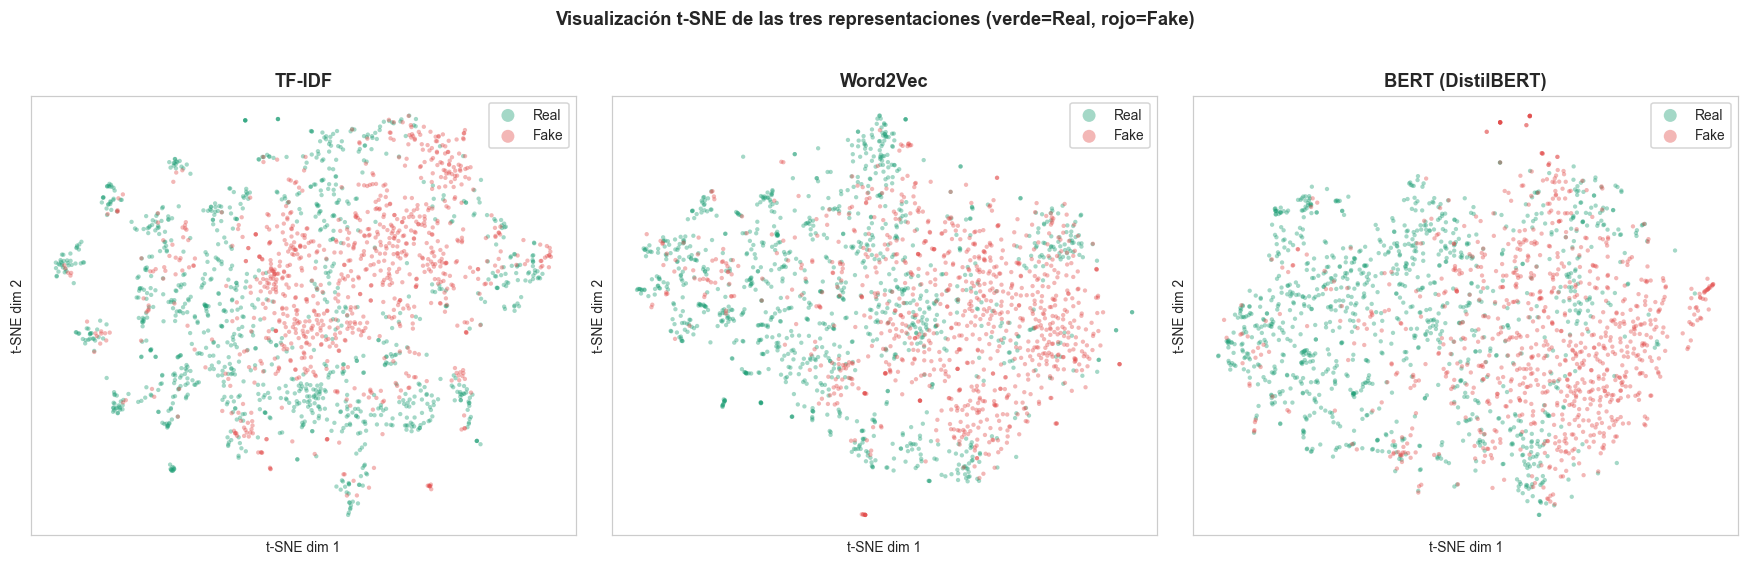

Cuanto más separados estén los grupos, mejor captura la representación las diferencias entre clases.


In [17]:
#Preparar subconjunto.
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

N_VIZ = min(2000, len(X_train_w2v))
idx_viz = np.random.default_rng(SEED).choice(len(X_train_w2v), N_VIZ, replace=False)
y_viz = y_train[idx_viz]

#TF-IDF
print('Reduciendo TF-IDF a 50 dims con SVD (ajustado en train completo)...')
svd = TruncatedSVD(n_components=50, random_state=SEED)
svd.fit(X_train_tfidf)                              #fit en train completo
tfidf_viz_50d = svd.transform(X_train_tfidf[idx_viz])  #transform solo la muestra

#Word2Vec
w2v_viz = X_train_w2v[idx_viz]

#BERT
if 'bert_embeddings_sample' not in globals():
    if os.path.exists('bert_sample.npy') and os.path.exists('bert_sample_y.npy'):
        bert_embeddings_sample = np.load('bert_sample.npy')
        y_bert_sample = np.load('bert_sample_y.npy')
        print('Cargada muestra BERT desde bert_sample.npy')
    else:
        raise FileNotFoundError(
            'No existe bert_embeddings_sample ni bert_sample.npy. '
            'Ejecuta antes la celda de generación de embeddings BERT.'
        )

print('Reduciendo BERT a 50 dims con PCA')
pca50 = PCA(n_components=50, random_state=SEED)

N_BERT_VIZ = min(N_VIZ, len(bert_embeddings_sample))
idx_viz_sample = np.random.default_rng(SEED).choice(
    len(bert_embeddings_sample),
    N_BERT_VIZ,
    replace=False
)

bert_viz_50d = pca50.fit_transform(bert_embeddings_sample[idx_viz_sample])
y_bert_viz = y_bert_sample[idx_viz_sample]

print('Explicación de varianza PCA (BERT, 50 componentes):')
print(f'  {pca50.explained_variance_ratio_.sum()*100:.1f}% de la varianza total')

#t-SNE compatible con distintas versiones de sklearn
tsne_params = dict(
    n_components=2,
    random_state=SEED,
    perplexity=40,
    max_iter=500,
    verbose=0
)

print('Ejecutando t-SNE para TF-IDF')
t0 = time.time()
tsne_tfidf = TSNE(**tsne_params).fit_transform(tfidf_viz_50d)
print(f'  {time.time()-t0:.1f}s')

print('Ejecutando t-SNE para Word2Vec')
t0 = time.time()
tsne_w2v = TSNE(**tsne_params).fit_transform(w2v_viz)
print(f'  {time.time()-t0:.1f}s')

print('Ejecutando t-SNE para BERT')
t0 = time.time()
tsne_bert = TSNE(**tsne_params).fit_transform(bert_viz_50d)
print(f'  {time.time()-t0:.1f}s')

#Visualización comparativa 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (tsne_tfidf, y_viz, 'TF-IDF'),
    (tsne_w2v, y_viz, 'Word2Vec'),
    (tsne_bert, y_bert_viz, 'BERT (DistilBERT)'),
]

colors_map = {0: '#1D9E75', 1: '#E24B4A'}
labels_map = {0: 'Real', 1: 'Fake'}

for ax, (data, labels, title) in zip(axes, configs):
    for cls in [0, 1]:
        mask = labels == cls
        ax.scatter(
            data[mask, 0],
            data[mask, 1],
            c=colors_map[cls],
            label=labels_map[cls],
            alpha=0.4,
            s=8,
            edgecolors='none'
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('t-SNE dim 1', fontsize=9)
    ax.set_ylabel('t-SNE dim 2', fontsize=9)

plt.suptitle(
    'Visualización t-SNE de las tres representaciones (verde=Real, rojo=Fake)',
    fontsize=12,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('fig_tsne_comparacion.png', bbox_inches='tight')
plt.show()

print('Cuanto más separados estén los grupos, mejor captura la representación las diferencias entre clases.')

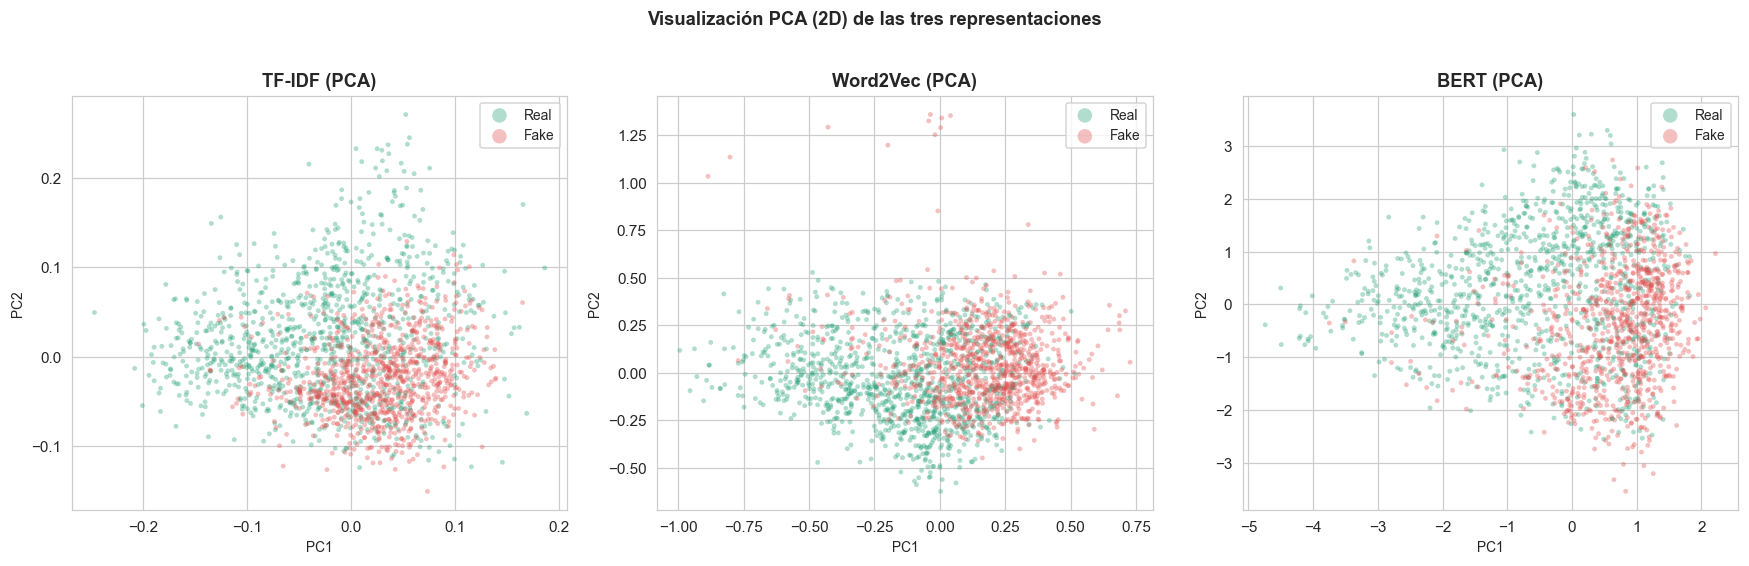

In [18]:
#PCA 2D comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pca2 = PCA(n_components=2, random_state=SEED)

pca_tfidf = pca2.fit_transform(tfidf_viz_50d)
pca_w2v = pca2.fit_transform(w2v_viz)
pca_bert = pca2.fit_transform(bert_viz_50d)

configs_pca = [
    (pca_tfidf, y_viz, 'TF-IDF (PCA)'),
    (pca_w2v, y_viz, 'Word2Vec (PCA)'),
    (pca_bert, y_bert_viz, 'BERT (PCA)'),
]

for ax, (data, labels, title) in zip(axes, configs_pca):
    for cls in [0, 1]:
        mask = labels == cls
        ax.scatter(
            data[mask, 0],
            data[mask, 1],
            c=colors_map[cls],
            label=labels_map[cls],
            alpha=0.35,
            s=10,
            edgecolors='none'
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)

plt.suptitle(
    'Visualización PCA (2D) de las tres representaciones',
    fontsize=12,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('fig_pca_comparacion.png', bbox_inches='tight')
plt.show()

---
## 7. Resumen comparativo de las representaciones

In [19]:
#Calidad de separación
def separabilidad(X, y):
  
    c0 = X[y == 0].mean(axis=0)
    c1 = X[y == 1].mean(axis=0)
    dist_inter = np.linalg.norm(c1 - c0)
    std0 = X[y == 0].std()
    std1 = X[y == 1].std()
    return dist_inter / ((std0 + std1) / 2)


sep_tfidf = separabilidad(tfidf_viz_50d, y_viz)
sep_w2v   = separabilidad(w2v_viz, y_viz)
sep_bert  = separabilidad(bert_viz_50d, y_bert_viz)

resumen = pd.DataFrame({
    'Representación': ['TF-IDF', 'Word2Vec', 'BERT (DistilBERT)'],
    'Dimensión salida': ['50.000 (sparse)', '300 (denso)', '768 (denso)'],
    'Tipo': ['Estadística', 'Semántica', 'Contextual'],
    'Contexto': ['No', 'No', 'Sí'],
    'Necesita GPU': ['No', 'No', 'Recomendable'],
    'Separabilidad ( mejor)': [f'{sep_tfidf:.3f}', f'{sep_w2v:.3f}', f'{sep_bert:.3f}']
})

print(resumen.to_string(index=False))

   Representación Dimensión salida        Tipo Contexto Necesita GPU Separabilidad ( mejor)
           TF-IDF  50.000 (sparse) Estadística       No           No                  2.154
         Word2Vec      300 (denso)   Semántica       No           No                  3.312
BERT (DistilBERT)      768 (denso)  Contextual       Sí Recomendable                  3.273


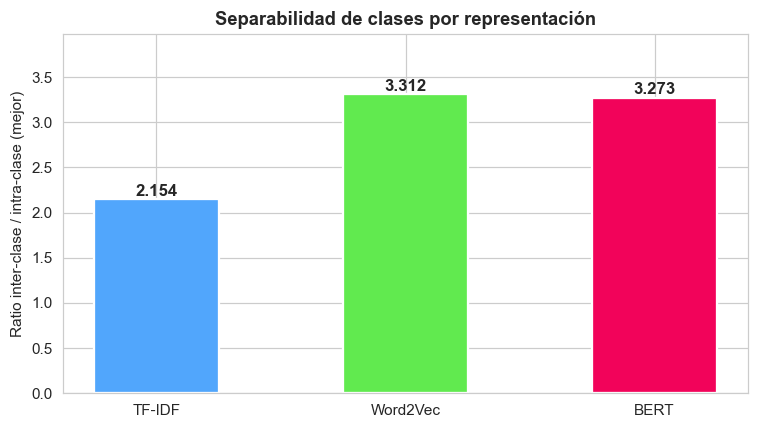


 La representación con mayor separabilidad es: Word2Vec


In [20]:
#Grafico de separabilidad
fig, ax = plt.subplots(figsize=(7, 4))

metodos = ['TF-IDF', 'Word2Vec', 'BERT']
valores  = [sep_tfidf, sep_w2v, sep_bert]
colores  = ["#51A6FC", "#61EA4F", "#F2035A"]

bars = ax.bar(metodos, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Separabilidad de clases por representación', fontweight='bold')
ax.set_ylabel('Ratio inter-clase / intra-clase (mejor)')
ax.set_ylim(0, max(valores) * 1.2)

plt.tight_layout()
plt.savefig('fig_separabilidad.png', bbox_inches='tight')
plt.show()

mejor = metodos[np.argmax(valores)]
print(f'\n La representación con mayor separabilidad es: {mejor}')

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluar_lr(X_train, X_val, y_train, y_val, nombre):
    clf = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_score)
    else:
        auc = np.nan

    return {
        'Representación': nombre,
        'Accuracy_val': accuracy_score(y_val, y_pred),
        'F1_val': f1_score(y_val, y_pred),
        'ROC_AUC_val': auc
    }

resultados_lr = []

resultados_lr.append(evaluar_lr(X_train_tfidf, X_val_tfidf, y_train, y_val, 'TF-IDF'))
resultados_lr.append(evaluar_lr(X_train_w2v, X_val_w2v, y_train, y_val, 'Word2Vec'))

#BERT completo solo se evalua si existen las matrices completas
if 'X_train_bert' in globals() and 'X_val_bert' in globals():
    resultados_lr.append(evaluar_lr(X_train_bert, X_val_bert, y_train, y_val, 'BERT embeddings'))
elif os.path.exists('bert_train.npy') and os.path.exists('bert_val.npy'):
    X_train_bert = np.load('bert_train.npy')
    X_val_bert = np.load('bert_val.npy')
    resultados_lr.append(evaluar_lr(X_train_bert, X_val_bert, y_train, y_val, 'BERT embeddings'))
else:
    print('No puede evaluarse por falta de archivos.')

df_resultados_lr = pd.DataFrame(resultados_lr)
df_resultados_lr

,Representación,Accuracy_val,F1_val,ROC_AUC_val
0,TF-IDF,0.956788,0.952249,0.991989
1,Word2Vec,0.910748,0.900665,0.968207
2,BERT embeddings,0.942646,0.936511,0.985346


In [22]:
filas_dim = [
    {
        'Representación': 'TF-IDF',
        'Train shape': X_train_tfidf.shape,
        'Val shape': X_val_tfidf.shape,
        'Test shape': X_test_tfidf.shape
    },
    {
        'Representación': 'Word2Vec',
        'Train shape': X_train_w2v.shape,
        'Val shape': X_val_w2v.shape,
        'Test shape': X_test_w2v.shape
    }
]

if 'X_train_bert' in globals() and 'X_val_bert' in globals() and 'X_test_bert' in globals():
    filas_dim.append({
        'Representación': 'BERT',
        'Train shape': X_train_bert.shape,
        'Val shape': X_val_bert.shape,
        'Test shape': X_test_bert.shape
    })
elif os.path.exists('bert_train.npy') and os.path.exists('bert_val.npy') and os.path.exists('bert_test.npy'):
    filas_dim.append({
        'Representación': 'BERT',
        'Train shape': np.load('bert_train.npy', mmap_mode='r').shape,
        'Val shape': np.load('bert_val.npy', mmap_mode='r').shape,
        'Test shape': np.load('bert_test.npy', mmap_mode='r').shape
    })
else:
    filas_dim.append({
        'Representación': 'BERT',
        'Train shape': 'solo muestra EDA',
        'Val shape': 'no generado',
        'Test shape': 'no generado'
    })

resumen_dimensiones = pd.DataFrame(filas_dim)
resumen_dimensiones

,Representación,Train shape,Val shape,Test shape
0,TF-IDF,"(50909, 50000)","(6364, 50000)","(6364, 50000)"
1,Word2Vec,"(50909, 300)","(6364, 300)","(6364, 300)"
2,BERT,"(50909, 768)","(6364, 768)","(6364, 768)"


In [23]:
print('=' * 55)
print('Archivos generados')
print('=' * 55)

archivos = [
    ('tfidf_train.npz',       'Matriz TF-IDF train (sparse)'),
    ('tfidf_val.npz',         'Matriz TF-IDF val (sparse)'),
    ('tfidf_test.npz',        'Matriz TF-IDF test (sparse)'),
    ('tfidf_vectorizer.pkl',  'Vectorizador TF-IDF serializado'),
    ('w2v_train.npy',         'Embeddings Word2Vec train'),
    ('w2v_val.npy',           'Embeddings Word2Vec val'),
    ('w2v_test.npy',          'Embeddings Word2Vec test'),
    ('word2vec_model.bin',    'Modelo Word2Vec entrenado'),
    ('bert_sample.npy',       'Muestra embeddings BERT para EDA'),
    ('bert_sample_y.npy',     'Etiquetas de la muestra BERT'),
    ('bert_train.npy',        'Embeddings BERT train'),
    ('bert_val.npy',          'Embeddings BERT val'),
    ('bert_test.npy',         'Embeddings BERT test'),
]

for fname, desc in archivos:
    existe = '✓' if os.path.exists(fname) else '✗ (no generado)'
    print(f'  {existe}  {fname:<30} {desc}')

print('\n Notebook 2 completado.')


Archivos generados
  ✓  tfidf_train.npz                Matriz TF-IDF train (sparse)
  ✓  tfidf_val.npz                  Matriz TF-IDF val (sparse)
  ✓  tfidf_test.npz                 Matriz TF-IDF test (sparse)
  ✓  tfidf_vectorizer.pkl           Vectorizador TF-IDF serializado
  ✓  w2v_train.npy                  Embeddings Word2Vec train
  ✓  w2v_val.npy                    Embeddings Word2Vec val
  ✓  w2v_test.npy                   Embeddings Word2Vec test
  ✓  word2vec_model.bin             Modelo Word2Vec entrenado
  ✓  bert_sample.npy                Muestra embeddings BERT para EDA
  ✓  bert_sample_y.npy              Etiquetas de la muestra BERT
  ✓  bert_train.npy                 Embeddings BERT train
  ✓  bert_val.npy                   Embeddings BERT val
  ✓  bert_test.npy                  Embeddings BERT test

 Notebook 2 completado.


## Conclusión del Notebook 2

A lo largo del notebook se han construido y comparado tres formas diferentes de representar las noticias del dataset,TF-IDF, Word2Vec y embeddings contextuales de DistilBERT. El objetivo principal ha sido transformar el texto en vectores válidos para los modelos de clasificación del Notebook 3, manteniendo en todo momento una metodología controlada para evitar fugas de información.

TF-IDF ha permitido capturar la importancia de palabras y bigramas dentro de cada noticia. Se ha empleado un vocabulario amplio filtrado, eliminando términos demasiado concretos, frecuentes y palabras de alto riesgo asociadas a fuentes o etiquetas.

Word2Vec ha aportado una visión complementaria. Para representar cada noticia se ha utilizado el promedio de los embeddings de palabras, obteniendo vectores compactos de 300 dimensiones. Esto tiene una limitación importante, y es que al promediar palabras se pierde el orden, la estructura del texto y parte del contexto global de la noticia.


Los embeddings contextuales con DistilBERT, permiten representar cada noticia teniendo en cuenta el contexto en el que aparecen las palabras. Se ha evitado aplicar una limpieza agresiva, para reducir el riesgo de aprendizaje por atajos.